# Cartesian Grid and Active Degrees of Freedom

A one-dimensional Cartesian grid provides a discrete coordinate representation for fields of $x$. The grid is built from a `CartesianAxis`, while an `ActiveSet1D` selects the degrees of freedom retained in a numerical problem.

```mermaid
classDiagram
    direction LR

    class CartesianAxis {
        +str name
        +float lower
        +float upper
        +int N
        +bool endpoint
        +float L
        +float delta
        +FloatArray values
    }

    class CartesianGrid1D {
        +CartesianAxis x
        +tuple shape
        +int size
    }

    class ActiveSet1D {
        +CartesianGrid1D grid
        +IntArray indices
        +FloatArray coordinates
        +int size
    }

    CartesianAxis <--* CartesianGrid1D : x
    CartesianGrid1D <-- ActiveSet1D : selects
```

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from physkit.core.grids import (
    CartesianAxis,
    ActiveSet1D, 
    CartesianGrid1D
)

## 1. Construct a Cartesian grid

Consider the closed spatial domain

$$
x\in[x_{\min},x_{\max}].
$$

The grid contains $N_x$ uniformly spaced coordinate samples. Because both endpoints are included,

$$
\Delta x=\frac{L_x}{N_x-1},
\qquad
L_x=x_{\max}-x_{\min}.
$$

In [11]:
grid = CartesianGrid1D(
    x_lower=0.0,
    x_upper=1.0,
    Nx=11,
    endpoint=True,
)

assert isinstance(grid.x, CartesianAxis)


## 2. Inspect the coordinate axis

The grid exposes its Cartesian axis as `grid.x`. Coordinate information therefore follows the hierarchy

```text
grid.x.lower
grid.x.upper
grid.x.N
grid.x.L
grid.x.delta
grid.x.values
```

A scalar field sampled on this grid is represented by a vector in $\mathbb{R}^{N_x}$ or $\mathbb{C}^{N_x}$.

In [12]:
print(f"x.type   = {type(grid.x)}")
print(f"x.lower  = {grid.x.lower}")
print(f"x.upper  = {grid.x.upper}")
print(f"x.N      = {grid.x.N}")
print(f"x.length = {grid.x.length}")
print(f"x.delta  = {grid.x.delta}")
print(f"x.values = {grid.x.values}")
print(f"x.shape  = {grid.shape}")
print(f"x.size   = {grid.size}")

x.type   = <class 'physkit.core.grids.CartesianAxis'>
x.lower  = 0.0
x.upper  = 1.0
x.N      = 11
x.length = 1.0
x.delta  = 0.1
x.values = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
x.shape  = (11,)
x.size   = 11


In [13]:
assert grid.shape == (grid.x.N,)
assert grid.size == grid.x.N
assert np.isclose(grid.x.values[0], grid.x.lower)
assert np.isclose(grid.x.values[-1], grid.x.upper)
assert np.isclose(grid.x.delta, grid.x.length / (grid.x.N - 1))

print("Grid checks passed.")

Grid checks passed.


## 3. All degrees of freedom

The complete grid state is

$$
\mathbf{u}=
\begin{bmatrix}
u_0 & u_1 & \cdots & u_{N_x-1}
\end{bmatrix}^{\mathsf T}.
$$

The active set containing every grid point has the index set

$$
\mathcal I_{\mathrm{all}}=\{0,1,\ldots,N_x-1\}.
$$

In [14]:
grid_all_dofs = ActiveSet1D(
    grid=grid,
    indices=np.arange(0, grid.x.N, dtype=np.int64),
)

## 4. Interior degrees of freedom

For an endpoint-inclusive grid, the boundary indices are $0$ and $N_x-1$. Removing these boundary degrees of freedom gives

$$
\mathcal I_{\mathrm{interior}}=\{1,2,\ldots,N_x-2\}.
$$

The corresponding active-state dimension is

$$
N_A=N_x-2.
$$

In [15]:
grid_interior_dofs = ActiveSet1D(
    grid=grid,
    indices=np.arange(1, grid.x.N - 1, dtype=np.int64),
)

## 5. Restrict a full state to the active state

Let a scalar field be sampled at every grid point:

$$
u_i=u(x_i).
$$

Restriction to the active indices produces

$$
\mathbf{u}_A=\mathbf{u}[\mathcal I_A].
$$

Numerically, the full state belongs to $\mathbb{R}^{N_x}$ and the interior state belongs to $\mathbb{R}^{N_A}$.

In the following code, the field

$$
u(x)=\sin(\pi x)
$$

is first evaluated at every coordinate in `grid.x.values`. This produces the complete grid state `u`. The active state `u_interior` is then constructed by selecting only the components whose indices are stored in `grid_interior_dofs.indices`.

The array shapes verify the change in numerical state space:

$$
\mathbf{u}\in\mathbb{R}^{N_x}
\longrightarrow
\mathbf{u}_A\in\mathbb{R}^{N_A}.
$$

In [16]:
# evaluate on all grid points
u = np.sin(np.pi * grid.x.values)

# select only the interior points
u_interior = u[grid_interior_dofs.indices]

# generate strings for output
str_u = np.array2string(
    u,
    precision=4,
    suppress_small=True,
    separator=", ",
)
str_u_interior = np.array2string(
    u_interior,
    precision=4,
    suppress_small=True,
    separator=", ",
)
print(f"u.shape          = {u.shape}")
print(f"u.interior.shape = {u_interior.shape}")
print(f"u \n\t= {str_u}")
print(f"u_interior \n\t= {str_u_interior}")

u.shape          = (11,)
u.interior.shape = (9,)
u 
	= [0.    , 0.309 , 0.5878, 0.809 , 0.9511, 1.    , 0.9511, 0.809 , 0.5878,
 0.309 , 0.    ]
u_interior 
	= [0.309 , 0.5878, 0.809 , 0.9511, 1.    , 0.9511, 0.809 , 0.5878, 0.309 ]


## 6. Reconstruct a full state

Suppose homogeneous Dirichlet boundary conditions are prescribed:

$$
u(x_{\min})=0,
\qquad
u(x_{\max})=0.
$$

A full grid vector can be reconstructed from the active vector by allocating a vector in $\mathbb{R}^{N_x}$ and inserting the active values at $\mathcal I_A$.

In [17]:
u_reconstructed = np.zeros(
    grid.shape,
    dtype=np.float64,
)

u_reconstructed[
    grid_interior_dofs.indices
] = u_interior

assert np.allclose(
    u_reconstructed,
    u,
)

u_reconstructed_string = np.array2string(
    u_reconstructed,
    precision=4,
    suppress_small=True,
    separator=", ",
)

print(
    f"Reconstructed grid state, "
    f"shape {u_reconstructed.shape}:"
)

print(u_reconstructed_string)

Reconstructed grid state, shape (11,):
[0.    , 0.309 , 0.5878, 0.809 , 0.9511, 1.    , 0.9511, 0.809 , 0.5878,
 0.309 , 0.    ]


## 7. Visualize active and boundary points

The boundary points are part of the grid but are excluded from the interior active set. This separation allows an operator to act only on unknown degrees of freedom while boundary values are imposed separately.

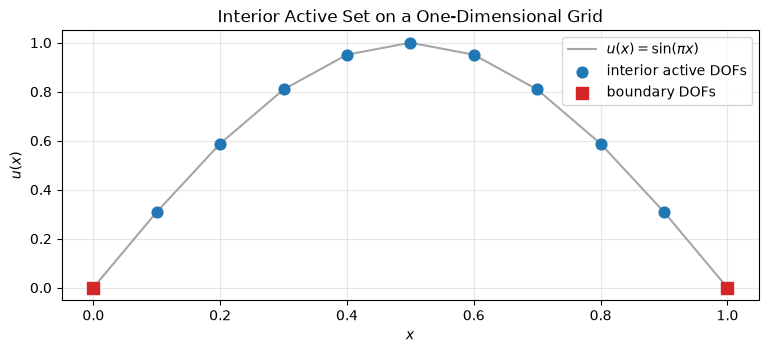

In [18]:
boundary_indices = np.array(
    [0, grid.x.N - 1],
    dtype=np.int64,
)

boundary_coordinates = grid.x.values[
    boundary_indices
]

boundary_values = u[
    boundary_indices
]

fig, ax = plt.subplots(
    figsize=(9, 3.5)
)

ax.plot(
    grid.x.values,
    u,
    color="0.65",
    linewidth=1.5,
    label=r"$u(x)=\sin(\pi x)$",
)

ax.scatter(
    grid_interior_dofs.coordinates,
    u_interior,
    s=60,
    color="tab:blue",
    label="interior active DOFs",
    zorder=3,
)

ax.scatter(
    boundary_coordinates,
    boundary_values,
    s=80,
    marker="s",
    color="tab:red",
    label="boundary DOFs",
    zorder=4,
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$u(x)$")
ax.set_title(
    "Interior Active Set on a One-Dimensional Grid"
)

ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 8. Restriction as a matrix operation

The indexing operation can also be represented by a restriction matrix

$$
R_A\in\mathbb{R}^{N_A\times N_x}.
$$

Each row of $R_A$ selects one active component of the full state, so

$$
\mathbf{u}_A=R_A\mathbf{u}.
$$

Its transpose embeds an active vector into the full grid with zeros at inactive indices:

$$
\mathbf{u}_{\mathrm{embedded}}=R_A^{\mathsf T}\mathbf{u}_A.
$$

In [19]:
restriction_matrix = np.zeros(
    (
        grid_interior_dofs.size,
        grid.size,
    ),
    dtype=np.float64,
)

restriction_matrix[
    np.arange(grid_interior_dofs.size),
    grid_interior_dofs.indices,
] = 1.0

u_interior_from_matrix = (
    restriction_matrix @ u
)

u_embedded_from_matrix = (
    restriction_matrix.T
    @ u_interior_from_matrix
)

assert np.allclose(
    u_interior_from_matrix,
    u_interior,
)

assert np.allclose(
    u_embedded_from_matrix,
    u_reconstructed,
)

print(
    "Restriction matrix shape:",
    restriction_matrix.shape,
)

print(
    np.array2string(
        restriction_matrix,
        precision=0,
        suppress_small=True,
    )
)

Restriction matrix shape: (9, 11)
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


## 9. Summary

The grid, full state, and active state have distinct roles:

- `grid.x.values` stores the coordinate samples $x_i$;
- $\mathbf{u}\in\mathbb{F}^{N_x}$ stores field values on the complete grid;
- `active.indices` defines the retained degrees of freedom $\mathcal I_A$;
- $\mathbf{u}_A\in\mathbb{F}^{N_A}$ stores the field values on the active set;
- $R_A$ maps the full representation to the active representation.

This provides the representation required to construct boundary-conditioned discrete operators in the active state space.